## 1.Inisialisasi & Import Pustaka
Sel kode di bawah berfungsi untuk menyiapkan lingkungan kerja dan memanggil pustaka (*library*) yang akan kita gunakan:
* **`ssl`**: Berfungsi untuk melewati (bypass) error verifikasi keamanan saat mesin OCR mendownload model AI dari internet.
* **`cv2` (OpenCV)**: Pustaka utama untuk memuat gambar, memanipulasi resolusi, dan memproses ruang warna.
* **`easyocr`**: Mesin AI berbasis Deep Learning untuk mendeteksi letak dan mengenali teks pada gambar.
* **`numpy`, `math`, `re`**: Digunakan untuk komputasi jarak koordinat kotak teks dan merapikan karakter atau tanda baca menggunakan *Regular Expression*.
* **`base64`**: Pustaka untuk mengubah format gambar asli menjadi kode teks murni, sehingga gambar bisa langsung disematkan (diinjeksi) ke dalam file HTML akhir.
* **`os`**: Digunakan untuk mengelola direktori dan path file, seperti membuat folder output secara otomatis serta menyimpan hasil ekstraksi ke lokasi yang ditentukan.

Di bagian akhir kode, kita menginisialisasi `easyocr.Reader` untuk bahasa Indonesia (`id`) dan Inggris (`en`). 

In [1]:
import ssl
import cv2
import easyocr
import numpy as np
import base64
import math
import matplotlib.pyplot as plt
import re
import os

ssl._create_default_https_context = ssl._create_unverified_context

print("Menginisialisasi Engine OCR...")
ocr_engine = easyocr.Reader(['id', 'en'], gpu=False)

Using CPU. Note: This module is much faster with a GPU.


Menginisialisasi Engine OCR...


## 2.Memuat dan Menyesuaikan Skala Gambar (Scaling)
Sel kode di bawah bertugas memuat file gambar dan mengoptimalkan ukurannya sebelum diolah oleh AI.

1. **Memuat Gambar:** Membaca file gambar dari lokasi penyimpanan lokal menggunakan `cv2.imread()`. Jika file tidak ditemukan, program akan menghentikan proses dan memunculkan error.
2. **Konversi Format Warna:** Mengubah format warna bawaan OpenCV (BGR) menjadi standar layar umum (RGB) agar warna gambar tidak memudar saat ditampilkan ke HTML nantinya.
3. **Mengecilkan Resolusi Dinamis:** Memproses gambar beresolusi sangat besar (contoh: 4K) akan membuat memori cepat penuh. Oleh karena itu, jika sisi terpanjang gambar melebihi 1500 piksel, kode akan menghitung rasio skalanya secara otomatis dan mengecilkan gambar tersebut secara proporsional agar tidak merusak ketajaman atau membuat gambar menjadi gepeng.

In [2]:
source_image_path = r"D:\Proyek Magang\RAG\Bagian-B-Layout-Aware-Text-Extraction\samples\Profile Image Studio  Let's Enable Digital Transformation with Us (2)_page-0003.jpg"
original_img = cv2.imread(source_image_path)

if original_img is None:
    raise FileNotFoundError("Error: Gambar tidak ditemukan pada path yang diberikan.")

max_resolution = 1500
rgb_image = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
img_height, img_width = rgb_image.shape[:2]

if max(img_height, img_width) > max_resolution:
    scaling_factor = max_resolution / max(img_height, img_width)
    target_width = int(img_width * scaling_factor)
    target_height = int(img_height * scaling_factor)
    rgb_image = cv2.resize(rgb_image, (target_width, target_height))
    print(f"Resolusi gambar disesuaikan menjadi {target_width}x{target_height}")

img_height, img_width = rgb_image.shape[:2]

Resolusi gambar disesuaikan menjadi 1500x837


## 3.Ekstraksi Teks & Filter Artefak (Pembersihan Noise)
Tahap ini adalah proses utama di mana AI mendeteksi karakter teks. Namun, hasil deteksi sering kali salah mengenali elemen desain sebagai teks. Sel kode di bawah dilengkapi algoritma untuk membuang artefak tersebut.

1. **Pemindaian Teks:** Perintah `readtext()` dieksekusi untuk mendapatkan teks dan koordinat letaknya.
2. **Filter Debu/Noda:** Menghapus hasil deteksi yang kotak pembatasnya (*bounding box*) sangat kecil, yang umumnya hanyalah noda piksel.
3. **Isolasi Logo Perusahaan:** Menggunakan perhitungan koordinat lokasi untuk mencari area spesifik letak logo. Jika terdeteksi, kode akan langsung merapikan ukuran kotaknya agar menutupi seluruh gambar logo.
4. **Pembunuh Artefak Pita:** Menghapus elemen dekoratif yang salah dideteksi sebagai teks. Jika kotak letaknya di atas gambar namun isinya tidak memiliki karakter huruf/angka yang valid (`isalnum`), maka kotak tersebut dibuang.

In [3]:
print("Memulai pemindaian teks...")
ocr_results = ocr_engine.readtext(rgb_image, paragraph=False, mag_ratio=2)

initial_detections = []

for (coord, detected_text, confidence) in ocr_results:
    top_l = (int(coord[0][0]), int(coord[0][1]))
    bot_r = (int(coord[2][0]), int(coord[2][1]))
    width_box = bot_r[0] - top_l[0]
    height_box = bot_r[1] - top_l[1]
    
    if width_box < 30 or height_box < 15:
        continue
    
    txt_normalized = detected_text.lower()
    is_pis_logo = False
    
    has_pis_keyword = "pis" in txt_normalized or "spis" in txt_normalized
    is_normal_pis = has_pis_keyword and top_l[1] < (img_height * 0.35) and bot_r[0] > (img_width * 0.5)
    is_unrecognized_ribbon = top_l[1] < (img_height * 0.35) and top_l[0] > (img_width * 0.5) and bot_r[0] > (img_width * 0.9) and width_box > 60 and height_box > 25
    if is_normal_pis or is_unrecognized_ribbon:
        bot_r = (bot_r[0] + 43, bot_r[1])
        batas_lebar_ideal = int(height_box * 1.5)
        
        if (bot_r[0] - top_l[0]) > batas_lebar_ideal:
            top_l = (bot_r[0] - batas_lebar_ideal, top_l[1])
            
        width_box = bot_r[0] - top_l[0]
        detected_text = "pis"
        is_pis_logo = True

    if not is_pis_logo and (width_box < 80 or height_box < 20):
        continue
        
    if not is_pis_logo and top_l[1] < (img_height * 0.35) and top_l[0] > (img_width * 0.50):
        if not any(c.isalnum() for c in detected_text):
            continue

    char_density = (width_box * height_box) / max(1, len(detected_text))
    initial_detections.append({
        "content": detected_text,
        "tl": top_l,
        "br": bot_r,
        "density": char_density,
        "fragments": [{"tl": top_l, "br": bot_r}]
    })

Memulai pemindaian teks...


d:\Proyek Magang\RAG\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


## 4.Mengelompokkan Teks yang Berdekatan (Clustering)
Keluaran asli dari mesin OCR sering memotong satu baris kalimat menjadi kata per kata. Sel kode di bawah digunakan untuk merapikan urutan bacaan tersebut.

**Metode yang dilakukan:**
Sistem akan memindai jarak koordinat antar-kotak kata. Jika letaknya sejajar secara vertikal dan jarak spasialnya cukup dekat, maka kotak-kotak tersebut disatukan menjadi satu kotak paragraf/kalimat yang lebih besar. Hal ini menjaga integritas susunan baris agar letaknya tetap masuk akal saat nanti dipindahkan ke HTML.

Mengelompokkan teks yang berdekatan...


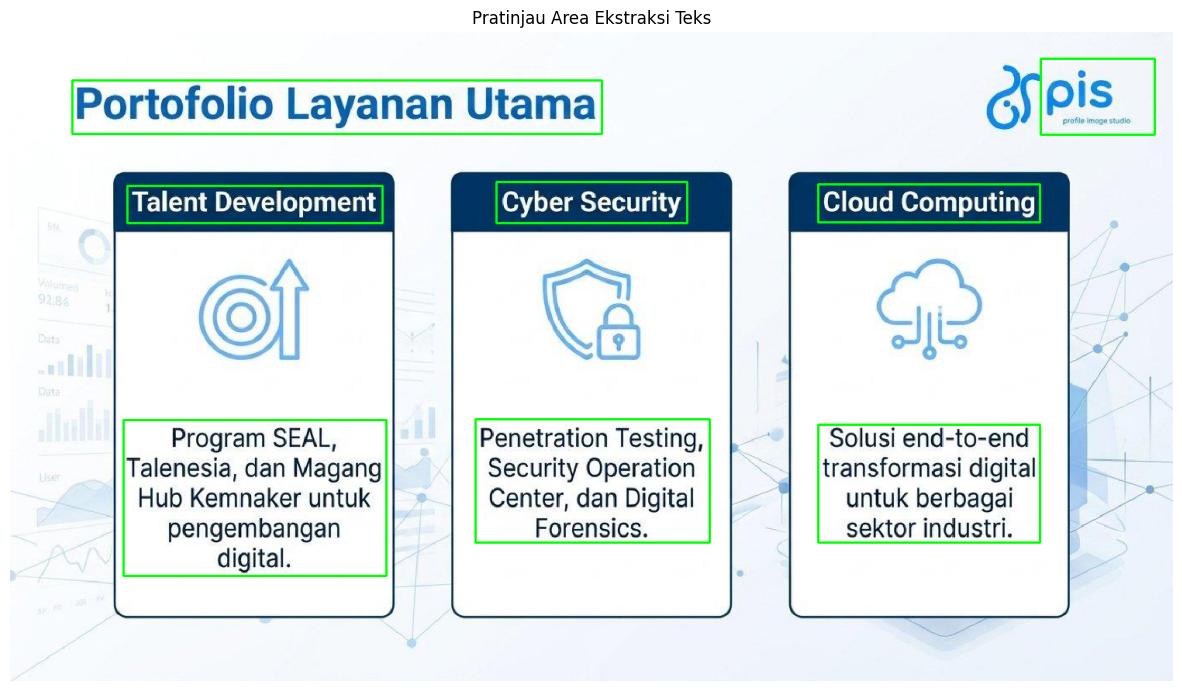

In [4]:
print("Mengelompokkan teks yang berdekatan...")

def group_text_regions(region_list, max_vertical_gap=60): 
    is_still_merging = True
    while is_still_merging:
        is_still_merging = False
        for idx1 in range(len(region_list)):
            for idx2 in range(idx1 + 1, len(region_list)):
                boxA, boxB = region_list[idx1], region_list[idx2]

                wA = boxA["br"][0] - boxA["tl"][0]
                wB = boxB["br"][0] - boxB["tl"][0] 
                
                ratio_w = max(wA, wB) / max(1, min(wA, wB))
                overlap_x = max(0, min(boxA["br"][0], boxB["br"][0]) - max(boxA["tl"][0], boxB["tl"][0]))

                size_A = math.sqrt(boxA["density"])
                size_B = math.sqrt(boxB["density"])
                ratio_font = max(size_A, size_B) / max(1, min(size_A, size_B))

                if overlap_x > (min(wA, wB) * 0.4) and ratio_w < 5.0 and ratio_font < 1.8:
                    if boxA["tl"][1] < boxB["tl"][1]:
                        upper_box, lower_box = boxA, boxB
                    else:
                        upper_box, lower_box = boxB, boxA

                    vertical_distance = lower_box["tl"][1] - upper_box["br"][1]

                    if -20 < vertical_distance < max_vertical_gap:
                        merged_tl = (min(boxA["tl"][0], boxB["tl"][0]), min(boxA["tl"][1], boxB["tl"][1]))
                        merged_br = (max(boxA["br"][0], boxB["br"][0]), max(boxA["br"][1], boxB["br"][1]))
                        merged_text = upper_box["content"] + " " + lower_box["content"]
                        
                        avg_density = (boxA["density"] + boxB["density"]) / 2
                        merged_fragments = boxA.get("fragments", [{"tl": boxA["tl"], "br": boxA["br"]}]) + \
                                           boxB.get("fragments", [{"tl": boxB["tl"], "br": boxB["br"]}])

                        region_list[idx1] = {
                            "content": merged_text, "tl": merged_tl, "br": merged_br,
                            "density": avg_density, "fragments": merged_fragments
                        }
                        region_list.pop(idx2)
                        is_still_merging = True
                        break
            if is_still_merging: break
    return region_list

final_text_blocks = group_text_regions(initial_detections, max_vertical_gap=60) 

preview_bbox = rgb_image.copy()
for block in final_text_blocks:
    cv2.rectangle(preview_bbox, block["tl"], block["br"], (0, 255, 0), 2)

plt.figure(figsize=(15, 10))
plt.imshow(preview_bbox)
plt.title("Pratinjau Area Ekstraksi Teks")
plt.axis('off')
plt.show()

## 5.Membersihkan Teks Bawaan Gambar (Inpainting)
Sel kode di bawah berfungsi untuk "menghapus" teks asli yang menempel pada gambar slide presentasi. Nantinya kita akan menempelkan teks digital (HTML) di atas gambar ini. Jika teks asli pada gambar tidak dihapus, maka teks digital kita akan bertumpuk dan berbayang dengan teks aslinya, sehingga sulit dibaca.

1. **Membuat Cetakan (Masking):** Program membuat sebuah kanvas hitam kosong, lalu menggambar blok putih tepat di koordinat tempat teks terdeteksi. Ini berfungsi sebagai "cetakan" untuk memberi tahu AI area mana saja yang harus dihapus.
2. **Proses Tambal (Inpainting):** Menggunakan fungsi `cv2.inpaint`, AI akan melihat area yang ditandai oleh cetakan tadi, lalu menambalnya menggunakan warna-warna piksel di sekitarnya. Hasil akhirnya, gambar latar belakang (*background*) menjadi bersih dari teks, seolah-olah teksnya sudah dihapus dengan penghapus.

Menghapus teks asli dari gambar...


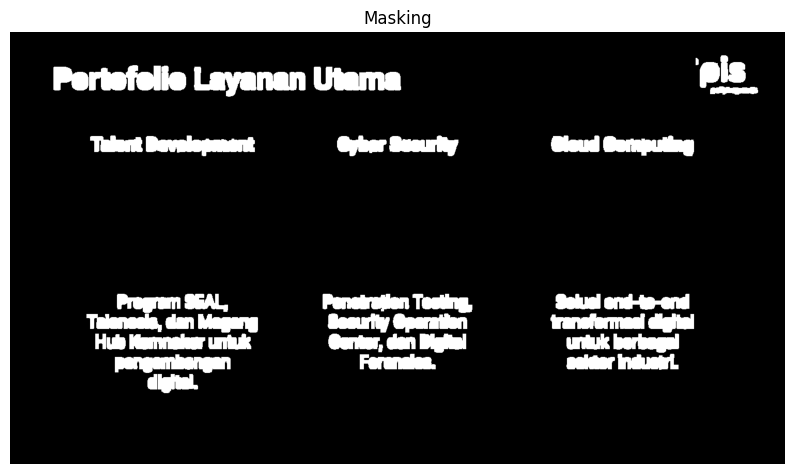

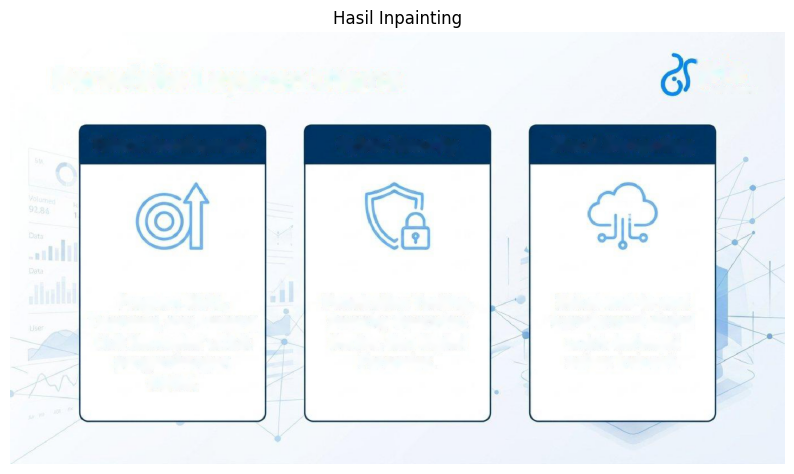

In [5]:
print("Menghapus teks asli dari gambar...")
inpainting_mask = np.zeros(rgb_image.shape[:2], dtype=np.uint8)

for block in final_text_blocks: 
    pt1, pt2 = block["tl"], block["br"]
    
    pad_val = 2
    crop_x1, crop_y1 = max(0, pt1[0] - pad_val), max(0, pt1[1] - pad_val)
    crop_x2, crop_y2 = min(img_width, pt2[0] + pad_val), min(img_height, pt2[1] + pad_val)
    
    region = rgb_image[crop_y1:crop_y2, crop_x1:crop_x2]
    
    if region.size > 0:
        gray_region = cv2.cvtColor(region, cv2.COLOR_RGB2GRAY)
        canny_outlines = cv2.Canny(gray_region, 50, 150)
        
        morph_kernel = np.ones((3, 3), np.uint8)
        thickened_outlines = cv2.dilate(canny_outlines, morph_kernel, iterations=2)
        
        contours_found, _ = cv2.findContours(thickened_outlines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(thickened_outlines, contours_found, -1, 255, -1)
        
        inpainting_mask[crop_y1:crop_y2, crop_x1:crop_x2] = cv2.bitwise_or(inpainting_mask[crop_y1:crop_y2, crop_x1:crop_x2], thickened_outlines)

clean_bg_image = cv2.inpaint(rgb_image, inpainting_mask, inpaintRadius=5, flags=cv2.INPAINT_TELEA)

plt.figure(figsize=(10, 10))
plt.imshow(inpainting_mask, cmap='gray')
plt.title("Masking")
plt.axis('off')
plt.show()

plt.figure(figsize=(10, 10))
plt.imshow(clean_bg_image)
plt.title("Hasil Inpainting")
plt.axis('off')
plt.show()

## 6.Merakit Hasil ke Halaman Web Interaktif (HTML)
Ini adalah tahap final. Sel kode di bawah akan menyatukan gambar yang sudah dibersihkan (*inpainting*) dengan teks yang sudah dirapikan (*clustering*) menjadi satu file halaman web (HTML).

1. **Mengubah Gambar Menjadi Teks (Base64):** Gambar latar belakang yang sudah bersih diubah formatnya menjadi string (teks) yang sangat panjang. Dengan cara ini, gambar bisa langsung ditanam di dalam file HTML tanpa harus memuat file gambar dari luar.
2. **Tata Letak Responsif:** Koordinat piksel dari hasil bacaan AI diubah menjadi nilai persentase CSS (`left: %` dan `top: %`). Ini memastikan teks akan duduk pas di tempat asalnya pada gambar, meskipun ukuran layar atau jendela browser kita perbesar/perkecil.
3. **Membuat Teks Bisa Diedit:** Setiap teks dibungkus dengan kode `contenteditable="true"`. Ini adalah fitur rahasia yang membuat teks di dalam gambar tersebut bisa kita blok, *copy*, atau ketik ulang layaknya di Microsoft Word.
4. **Menambahkan Pop-up Editor:** Program menyisipkan skrip *JavaScript* yang mendeteksi kapan kita memblok teks. Saat teks diblok, akan muncul menu pop-up otomatis untuk mengubah huruf menjadi tebal (Bold), miring (Italic), atau mengubah warnanya.
5. **Simpan File:** Semua racikan tersebut disimpan ke dalam file baru bernama `layout_extraction_result.html` yang siap dibuka di browser apa saja.

In [6]:
print("Membangun dokumen HTML interaktif...")

def format_punctuation(raw_str): 
    res = re.sub(r'[;,]+', ',', raw_str) 
    res = re.sub(r',\s*', ', ', res) 
    return res.strip() 

_, encoded_img = cv2.imencode('.jpg', cv2.cvtColor(clean_bg_image, cv2.COLOR_RGB2BGR))
base64_bg = base64.b64encode(encoded_img).decode('utf-8') 

html_markup = f""" 
<!DOCTYPE html> 
<html lang="id"> 
<head> 
    <meta charset="UTF-8"> 
    <meta name="viewport" content="width=device-width, initial-scale=1.0"> 
    <title>Layout Aware Extraction - Final Editor</title> 
    <style> 
        body {{ margin: 0; padding: 30px 20px; background-color: #f8f9fa; font-family: system-ui, sans-serif; display: flex; flex-direction: column; align-items: center; }} 
        .slide-canvas {{ container-type: inline-size; position: relative; width: 100%; max-width: 1200px; aspect-ratio: {img_width} / {img_height}; background-image: url(data:image/jpeg;base64,{base64_bg}); background-size: 100% 100%; background-repeat: no-repeat; box-shadow: 0 10px 25px rgba(0,0,0,0.1); border-radius: 8px; overflow: hidden; }} 
        .interactive-text {{ position: absolute; cursor: text; outline: none; white-space: normal; line-height: 1.3; letter-spacing: -0.3px; text-shadow: 0px 1px 2px rgba(0,0,0,0.3); transition: box-shadow 0.2s ease, background-color 0.2s ease; transform: translate(-50%, -50%); }} 
        .interactive-text:focus {{ background-color: rgba(0, 123, 255, 0.1); box-shadow: 0 0 0 2px #007bff; border-radius: 4px; z-index: 10; }} 
        .format-menu {{ position: absolute; display: none; background: #fff; border-radius: 8px; box-shadow: 0 4px 20px rgba(0,0,0,0.15); padding: 6px 10px; z-index: 1000; align-items: center; gap: 6px; border: 1px solid #ddd; font-family: sans-serif; }}
        .action-btn {{ background: transparent; border: none; cursor: pointer; padding: 6px; min-width: 28px; height: 28px; font-size: 15px; border-radius: 4px; color: #333; font-weight: bold; transition: 0.2s; display: inline-flex; align-items: center; justify-content: center; }}
        .action-btn:hover {{ background: #e9ecef; color: #007bff; }}
        
        /* Style Khusus untuk Tombol Warna Teks (T) */
        .color-btn-wrapper {{ position: relative; width: 28px; height: 28px; display: inline-flex; align-items: center; justify-content: center; border-radius: 4px; transition: 0.2s; cursor: pointer; }}
        .color-btn-wrapper:hover {{ background: #e9ecef; color: #007bff; }}
        .color-icon-t {{ font-weight: 800; font-size: 16px; font-family: serif; color: #333; pointer-events: none; border-bottom: 3px solid #ff0000; line-height: 14px; padding-bottom: 2px; }}
        .color-picker-input {{ position: absolute; top: 0; left: 0; width: 100%; height: 100%; opacity: 0; cursor: pointer; }}
        
        .font-dropdown {{ padding: 4px 6px; border: 1px solid #ccc; border-radius: 4px; font-size: 14px; outline: none; cursor: pointer; background: #fff; height: 28px; }}
        .size-display {{ font-size: 14px; font-weight: 600; min-width: 22px; text-align: center; display: inline-block; }}
        .separator-line {{ width: 1px; height: 20px; background: #d1d5db; margin: 0 2px; }}
    </style> 
</head> 
<body> 
    <div id="textEditorMenu" class="format-menu">
        <select class="font-dropdown" onchange="changeFontFamily(this.value)" title="Ubah Font">
            <option value="system-ui, sans-serif">System Default</option>
            <option value="Inter, sans-serif">Inter</option>
            <option value="Arial, sans-serif">Arial</option>
            <option value="'Times New Roman', serif">Times New Roman</option>
            <option value="'Courier New', monospace">Courier</option>
        </select>
        <div class="separator-line"></div>
        <button class="action-btn" onclick="changeFontSize(-1)" title="Perkecil Text">-</button>
        <span id="fontSizeDisplay" class="size-display">14</span>
        <button class="action-btn" onclick="changeFontSize(1)" title="Perbesar Text">+</button>
        <div class="separator-line"></div>
        <button class="action-btn" onclick="applyFormat('bold')" title="Bold">B</button>
        <button class="action-btn" style="font-style: italic;" onclick="applyFormat('italic')" title="Italic">I</button>
        <button class="action-btn" style="text-decoration: underline;" onclick="applyFormat('underline')" title="Underline">U</button>
        
        <div class="color-btn-wrapper" title="Ubah Warna Teks">
            <span class="color-icon-t">T</span>
            <input type="color" class="color-picker-input" onchange="applyColor(this.value)">
        </div>

        <div class="separator-line"></div>
        <button class="action-btn" onclick="applyFormat('justifyLeft')" title="Rata Kiri">
            <svg width="16" height="16" fill="currentColor" viewBox="0 0 16 16"><path fill-rule="evenodd" d="M2 12.5a.5.5 0 0 1 .5-.5h7a.5.5 0 0 1 0 1h-7a.5.5 0 0 1-.5-.5zm0-3a.5.5 0 0 1 .5-.5h11a.5.5 0 0 1 0 1h-11a.5.5 0 0 1-.5-.5zm0-3a.5.5 0 0 1 .5-.5h7a.5.5 0 0 1 0 1h-7a.5.5 0 0 1-.5-.5zm0-3a.5.5 0 0 1 .5-.5h11a.5.5 0 0 1 0 1h-11a.5.5 0 0 1-.5-.5z"/></svg>
        </button>
        <button class="action-btn" onclick="applyFormat('justifyCenter')" title="Rata Tengah">
            <svg width="16" height="16" fill="currentColor" viewBox="0 0 16 16"><path fill-rule="evenodd" d="M4 12.5a.5.5 0 0 1 .5-.5h7a.5.5 0 0 1 0 1h-7a.5.5 0 0 1-.5-.5zm-2-3a.5.5 0 0 1 .5-.5h11a.5.5 0 0 1 0 1h-11a.5.5 0 0 1-.5-.5zm2-3a.5.5 0 0 1 .5-.5h7a.5.5 0 0 1 0 1h-7a.5.5 0 0 1-.5-.5zm-2-3a.5.5 0 0 1 .5-.5h11a.5.5 0 0 1 0 1h-11a.5.5 0 0 1-.5-.5z"/></svg>
        </button>
        <button class="action-btn" onclick="applyFormat('justifyRight')" title="Rata Kanan">
            <svg width="16" height="16" fill="currentColor" viewBox="0 0 16 16"><path fill-rule="evenodd" d="M6 12.5a.5.5 0 0 1 .5-.5h7a.5.5 0 0 1 0 1h-7a.5.5 0 0 1-.5-.5zm-4-3a.5.5 0 0 1 .5-.5h11a.5.5 0 0 1 0 1h-11a.5.5 0 0 1-.5-.5zm4-3a.5.5 0 0 1 .5-.5h7a.5.5 0 0 1 0 1h-7a.5.5 0 0 1-.5-.5zm-4-3a.5.5 0 0 1 .5-.5h11a.5.5 0 0 1 0 1h-11a.5.5 0 0 1-.5-.5z"/></svg>
        </button>
        <button class="action-btn" onclick="applyFormat('justifyFull')" title="Rata Kiri Kanan (Justify)">
            <svg width="16" height="16" fill="currentColor" viewBox="0 0 16 16"><path fill-rule="evenodd" d="M2 12.5a.5.5 0 0 1 .5-.5h11a.5.5 0 0 1 0 1h-11a.5.5 0 0 1-.5-.5zm0-3a.5.5 0 0 1 .5-.5h11a.5.5 0 0 1 0 1h-11a.5.5 0 0 1-.5-.5zm0-3a.5.5 0 0 1 .5-.5h11a.5.5 0 0 1 0 1h-11a.5.5 0 0 1-.5-.5zm0-3a.5.5 0 0 1 .5-.5h11a.5.5 0 0 1 0 1h-11a.5.5 0 0 1-.5-.5z"/></svg>
        </button>
    </div>
    <div class="slide-canvas"> 
""" 

for block in final_text_blocks: 
    sanitized_text = format_punctuation(block["content"]) 
    sanitized_text = re.sub(r'(Lokasi:|Website:)', r'<span style="font-weight: 800;">\1</span>', sanitized_text, flags=re.IGNORECASE)

    cx = (block["tl"][0] + block["br"][0]) / 2
    cy = (block["tl"][1] + block["br"][1]) / 2 
    box_w = block["br"][0] - block["tl"][0] 
    box_h = block["br"][1] - block["tl"][1] 
    
    crop_x1, crop_y1 = max(0, block["tl"][0]), max(0, block["tl"][1]) 
    crop_x2, crop_y2 = min(img_width, block["br"][0]), min(img_height, block["br"][1]) 
    region = rgb_image[crop_y1:crop_y2, crop_x1:crop_x2] 
    
    if region.size > 0: 
        gray_region = cv2.cvtColor(region, cv2.COLOR_RGB2GRAY) 
        _, binary_img = cv2.threshold(gray_region, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU) 
        if np.count_nonzero(binary_img) > (binary_img.size / 2): binary_img = cv2.bitwise_not(binary_img) 
            
        ink_pixels = region[binary_img == 255] 
        if len(ink_pixels) > 0: 
            mean_color = np.mean(ink_pixels, axis=0) 
            font_color = f"rgb({int(mean_color[0])}, {int(mean_color[1])}, {int(mean_color[2])})" 
        else: font_color = "#000000" 
    else: font_color = "#000000" 

    fragments = block.get("fragments", [{"tl": block["tl"], "br": block["br"]}])
    align_style = "center" 
    
    if len(fragments) > 1:
        gaps_left = [frag["tl"][0] - block["tl"][0] for frag in fragments]
        gaps_right = [block["br"][0] - frag["br"][0] for frag in fragments]
        if np.mean(gaps_left) < np.mean(gaps_right) * 0.6: align_style = "left"
        elif np.mean(gaps_right) < np.mean(gaps_left) * 0.6: align_style = "right"

    pct_left, pct_top, pct_width = (cx / img_width) * 100, (cy / img_height) * 100, ((box_w * 1.05) / img_width) * 100 
    
    calc_lines = max(1, round(math.sqrt((box_h / max(1, box_w)) * max(1, len(sanitized_text)) * 0.42)))
    size_px = min((box_h / calc_lines) * 0.85, (box_w * calc_lines) / max(1, len(sanitized_text) * 0.55))
    weight_css = 700 if ((box_w / max(1, box_h)) > 3.0 and len(sanitized_text) < 40) or len(sanitized_text) < 20 else 500
    size_cqw = (size_px / img_width) * 100 
    
    html_markup += f""" 
        <div class="interactive-text" 
             style="left: {pct_left:.3f}%; top: {pct_top:.3f}%; width: {pct_width:.3f}%; font-size: {size_cqw:.3f}cqw; font-weight: {weight_css}; color: {font_color}; text-align: {align_style}; font-family: 'Inter', sans-serif;" 
             contenteditable="true"> 
            {sanitized_text} 
        </div> 
    """

html_markup += """ 
    </div> 
    <script>
        const formatMenu = document.getElementById('textEditorMenu');
        const editableElements = document.querySelectorAll('.interactive-text');
        let activeElement = null;

        editableElements.forEach(el => {
            el.addEventListener('focus', (e) => {
                activeElement = e.target;
                updateMenuPosition(e.target);
                updateFontDisplay();
            });
            
            el.addEventListener('keyup', () => updateMenuPosition(activeElement));
            el.addEventListener('mouseup', () => updateMenuPosition(activeElement));
        });

        function updateMenuPosition(targetEl) {
            if (!targetEl) return;
            const bounds = targetEl.getBoundingClientRect();
            formatMenu.style.display = 'flex';
            formatMenu.style.top = `${bounds.top + window.scrollY - 55}px`;
            formatMenu.style.left = `${bounds.left + window.scrollX + (bounds.width / 2) - (formatMenu.offsetWidth / 2)}px`;
        }

        function updateFontDisplay() {
            if (!activeElement) return;
            const currentSize = window.getComputedStyle(activeElement).fontSize;
            document.getElementById('fontSizeDisplay').innerText = Math.round(parseFloat(currentSize));
        }

        function changeFontSize(step) {
            if (!activeElement) return;
            let currentSize = parseFloat(window.getComputedStyle(activeElement).fontSize);
            let newSize = currentSize + step;
            activeElement.style.fontSize = newSize + 'px';
            document.getElementById('fontSizeDisplay').innerText = Math.round(newSize);
            updateMenuPosition(activeElement);
        }

        function changeFontFamily(fontName) {
            if (!activeElement) return;
            activeElement.style.fontFamily = fontName;
        }
        
        // Fungsi baru untuk mengganti warna teks
        function applyColor(hexColor) {
            document.execCommand('foreColor', false, hexColor);
            if(activeElement) activeElement.focus();
        }

        document.addEventListener('mousedown', (e) => {
            if (!e.target.classList.contains('interactive-text') && !formatMenu.contains(e.target)) {
                formatMenu.style.display = 'none';
                activeElement = null;
            }
        });

        function applyFormat(actionCmd) {
            document.execCommand(actionCmd, false, null);
            if(activeElement) activeElement.focus();
        }
    </script>
</body> 
</html> 
""" 

output_dir = r"D:\Proyek Magang\RAG\Bagian-B-Layout-Aware-Text-Extraction\output"
output_file = os.path.join(output_dir, "layout_extraction_result.html")
with open(output_file, "w", encoding="utf-8") as file_out:
    file_out.write(html_markup)

print(f"Proses selesai!")
print(f"File tersimpan di: {output_file}")

Membangun dokumen HTML interaktif...
Proses selesai!
File tersimpan di: D:\Proyek Magang\RAG\Bagian-B-Layout-Aware-Text-Extraction\output\layout_extraction_result.html
